In [1]:
# Importation du fichier CSV
colis_df <- read.csv(
  "Colisageautomatique.csv",
  sep = ";",
  header = TRUE,
  stringsAsFactors = FALSE,
  fill = TRUE,
  quote = ""
)

# Aperçu rapide
head(colis_df)

,id,numero,date_introduction,observations,bl_suppression,date_suppression,date_modification,date_creation,gp_situation_id,quantite,⋯,qte_psc_sortie_chaine,qte_psc_engagement,qte_psc_entree_cond,qte_psc_sortie_cond,has_resrvation_global,generateur_fiche_colisage,has_resrvation_global_tissu,has_resrvation_global_fourniture,date_reservation_globale,qte_envoi_intervenant
,<int>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>
1,30345,112565,10/06/2025,NA,f,NA,NA,NA,NA,1317,⋯,NA,NA,NA,NA,,1,,,,NA
2,30346,4522931864,10/06/2025,NA,f,NA,NA,NA,NA,1032,⋯,NA,NA,NA,NA,,NA,,,,NA
3,30347,4522927321,10/06/2025,NA,f,NA,NA,NA,NA,2010,⋯,NA,NA,NA,NA,,NA,,,,NA
4,30348,4522931084,10/06/2025,NA,f,NA,NA,NA,NA,1520,⋯,NA,NA,NA,NA,,NA,,,,NA
5,30349,4522928874,10/06/2025,NA,f,NA,NA,NA,NA,1520,⋯,NA,NA,NA,NA,,NA,,,,NA
6,30350,4522931507,10/06/2025,NA,f,NA,NA,NA,NA,2010,⋯,NA,NA,NA,NA,,NA,,,,NA


**Nettoyage**

*   Supprime les colonnes avec NA

*   Supprime les doublons

*   Conversion des colonnes de dates





In [2]:
# Supprimer uniquement les colonnes entièrement vides (NA ou chaînes vides)
cols_all_na <- sapply(colis_df, function(x) all(is.na(x) | x == ""))
colis_df_clean <- colis_df[, !cols_all_na]

# Supprimer les doublons (lignes identiques)
colis_df_clean <- unique(colis_df_clean)

nb_doublons <- sum(duplicated(colis_df_clean))
cat("Nombre de doublons restants :", nb_doublons, "\n")

Nombre de doublons restants : 0 


In [3]:
# Fonction utilitaire de conversion en date (format jour/mois/année)
convert_to_date <- function(df, colname) {
  if (colname %in% names(df)) {
    df[[colname]] <- as.Date(df[[colname]], format = "%d/%m/%Y")
  }
  return(df)
}

# Liste des colonnes de dates à convertir (adapter au vrai nom exact des colonnes)
cols_dates <- c(
  "date_introduction",
  "date_livraison",
  "chd..date.prévue.",
  "cdd..date.réelle."
)

for (cn in cols_dates) {
  colis_df_clean <- convert_to_date(colis_df_clean, cn)
}

In [4]:
str(colis_df_clean[, cols_dates])
head(colis_df_clean[, cols_dates])

'data.frame':	3642 obs. of  4 variables:
 $ date_introduction: Date, format: "2025-06-10" "2025-06-10" ...
 $ date_livraison   : Date, format: "2025-06-24" "2026-02-23" ...
 $ chd..date.prévue.: Date, format: "2025-06-24" "2026-02-23" ...
 $ cdd..date.réelle.: Date, format: "2025-06-24" "2026-03-04" ...


,date_introduction,date_livraison,chd..date.prévue.,cdd..date.réelle.
,<date>,<date>,<date>,<date>
1,2025-06-10,2025-06-24,2025-06-24,2025-06-24
2,2025-06-10,2026-02-23,2026-02-23,2026-03-04
3,2025-06-10,2026-02-23,2026-02-23,2026-03-04
4,2025-06-10,2026-02-23,2026-02-23,2026-03-04
5,2025-06-10,2026-02-23,2026-02-23,2026-03-04
6,2025-06-10,2026-02-23,2026-02-23,2026-03-04


**Traitement**

*   Calcul du retard + colonne binaire
*   Fonction de catégorisation du retard + application
*   Aperçu des colonnes clés
*   Chargement de *ggplot2*
*   Graphique est_en_retard
*   Graphique type_retard










In [5]:
# 1) Création de la colonne numeric 'retard' (différence entre cdd et chd, en jours)
# Noms supposés des colonnes: 'chd..date.prévue.' et 'cdd..date.réelle.' déjà au format Date

if ("chd..date.prévue." %in% names(colis_df_clean) & "cdd..date.réelle." %in% names(colis_df_clean)) {
  colis_df_clean$retard <- as.numeric(colis_df_clean$cdd..date.réelle. - colis_df_clean$chd..date.prévue.)
} else {
  # Si les noms sont différents, on affiche les noms disponibles pour ajuster ensuite
  print(names(colis_df_clean))
}

# 2) Colonne binaire est_en_retard
colis_df_clean$est_en_retard <- ifelse(!is.na(colis_df_clean$retard) & colis_df_clean$retard > 0, TRUE, FALSE)

In [6]:
# 3) Catégorisation du retard
categoriser_retard <- function(jours) {
  if (is.na(jours)) {
    return(NA_character_)
  } else if (jours <= 0) {
    return("Pas de retard")
  } else if (jours <= 3) {
    return("Léger")
  } else if (jours <= 7) {
    return("Moyen")
  } else {
    return("Important")
  }
}

colis_df_clean$type_retard <- vapply(colis_df_clean$retard, categoriser_retard, character(1))

In [7]:
# 4) Aperçu des colonnes clés
print(head(colis_df_clean[, c(
  "date_introduction",
  "date_livraison",
  "chd..date.prévue.",
  "cdd..date.réelle.",
  "retard",
  "est_en_retard",
  "type_retard"
)]))

  date_introduction date_livraison chd..date.prévue. cdd..date.réelle. retard
1        2025-06-10     2025-06-24        2025-06-24        2025-06-24      0
2        2025-06-10     2026-02-23        2026-02-23        2026-03-04      9
3        2025-06-10     2026-02-23        2026-02-23        2026-03-04      9
4        2025-06-10     2026-02-23        2026-02-23        2026-03-04      9
5        2025-06-10     2026-02-23        2026-02-23        2026-03-04      9
6        2025-06-10     2026-02-23        2026-02-23        2026-03-04      9
  est_en_retard   type_retard
1         FALSE Pas de retard
2          TRUE     Important
3          TRUE     Important
4          TRUE     Important
5          TRUE     Important
6          TRUE     Important


In [8]:
# 5) Visualisation simple: répartition des retards (équivalent countplot)

# Installer/charger ggplot2 si besoin
if (!"ggplot2" %in% rownames(installed.packages())) {
  install.packages("ggplot2")
}
library(ggplot2)

Warning message:
"package 'ggplot2' was built under R version 4.5.2"


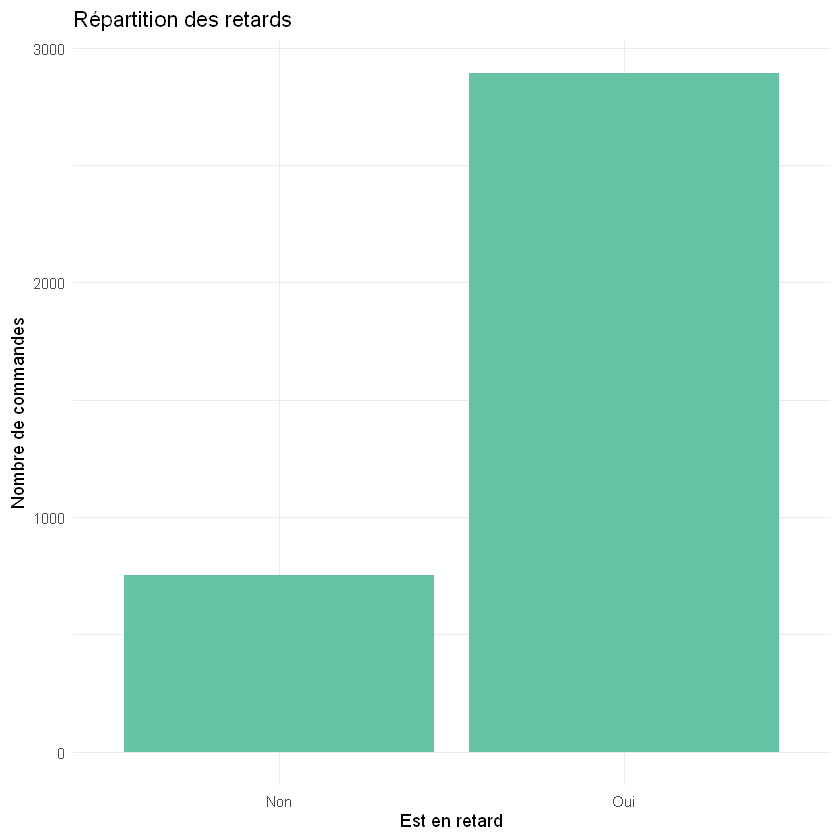

In [9]:
# Plot binaire est_en_retard
p1 <- ggplot(colis_df_clean, aes(x = est_en_retard)) +
  geom_bar(fill = "#66c2a5") +
  scale_x_discrete(labels = c("FALSE" = "Non", "TRUE" = "Oui")) +
  labs(
    title = "Répartition des retards",
    x = "Est en retard",
    y = "Nombre de commandes"
  ) +
  theme_minimal()

print(p1)

In [10]:
# 6) Logique d'alerte avancée

# Date du jour (système R)
aujourdhui <- Sys.Date()

# Alerte simple: cdd > chd
colis_df_clean$alerte_retard_reel <- ifelse(
  !is.na(colis_df_clean$cdd..date.réelle.) &
    !is.na(colis_df_clean$chd..date.prévue.) &
    colis_df_clean$cdd..date.réelle. > colis_df_clean$chd..date.prévue.,
  TRUE,
  FALSE
)

# Alerte détaillée (livré à temps, retard confirmé, en retard non livré, livraison prévue)
detecter_alerte <- function(date_prevue, date_reelle, today) {
  if (!is.na(date_reelle)) {
    if (date_reelle > date_prevue) {
      return("Retard confirmé")
    } else {
      return("Livré à temps")
    }
  } else {
    if (date_prevue < today) {
      return("En retard non livré")
    } else {
      return("Livraison prévue")
    }
  }
}

In [11]:
colis_df_clean$alerte_retard <- mapply(
  detecter_alerte,
  colis_df_clean$chd..date.prévue.,
  colis_df_clean$cdd..date.réelle.,
  MoreArgs = list(today = aujourdhui)
)

# Nombre de lignes par type d'alerte
print(table(colis_df_clean$alerte_retard, useNA = "ifany"))


  Livré à temps Retard confirmé 
            752            2890 


In [12]:
# Calcul nb_jours_retard (comme ta fonction calculer_retard)
calculer_retard <- function(date_prevue, date_reelle, today) {
  if (!is.na(date_reelle)) {
    return(as.numeric(date_reelle - date_prevue))
  } else if (date_prevue < today) {
    return(as.numeric(today - date_prevue))
  } else {
    return(0)
  }
}

colis_df_clean$nb_jours_retard <- mapply(
  calculer_retard,
  colis_df_clean$chd..date.prévue.,
  colis_df_clean$cdd..date.réelle.,
  MoreArgs = list(today = aujourdhui)
)

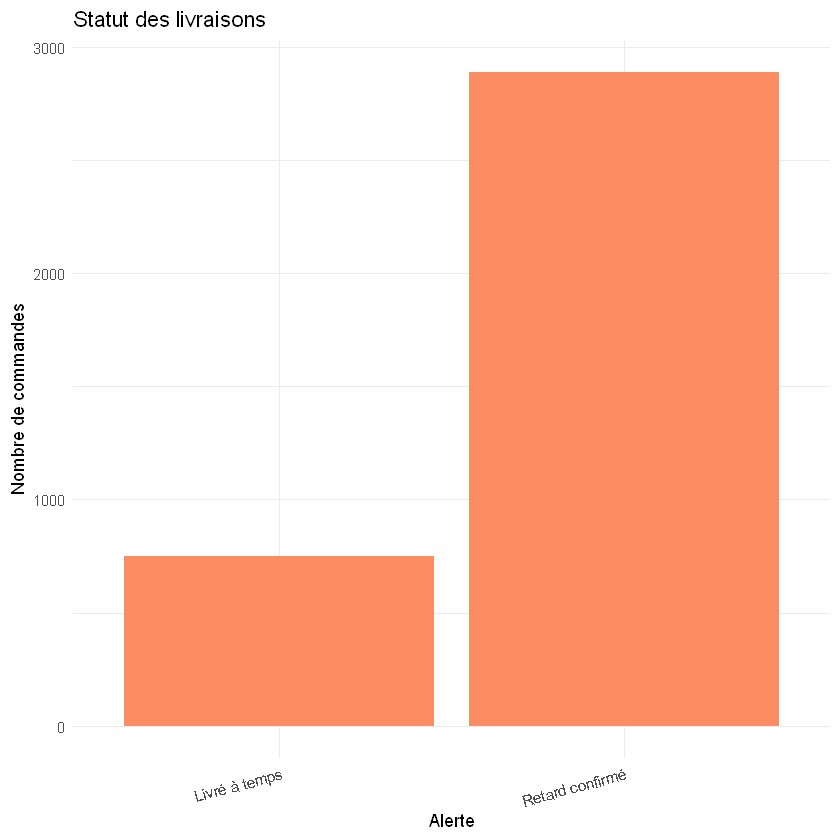

In [13]:
# Visualisation du statut des livraisons (alerte_retard)
p3 <- ggplot(colis_df_clean, aes(x = alerte_retard)) +
  geom_bar(fill = "#fc8d62") +
  labs(
    title = "Statut des livraisons",
    x = "Alerte",
    y = "Nombre de commandes"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 15, hjust = 1))

print(p3)

In [14]:
# Aperçu final des colonnes de retard
print(head(colis_df_clean[, c(
  "chd..date.prévue.",
  "cdd..date.réelle.",
  "retard",
  "est_en_retard",
  "type_retard",
  "alerte_retard",
  "nb_jours_retard"
)]))

  chd..date.prévue. cdd..date.réelle. retard est_en_retard   type_retard
1        2025-06-24        2025-06-24      0         FALSE Pas de retard
2        2026-02-23        2026-03-04      9          TRUE     Important
3        2026-02-23        2026-03-04      9          TRUE     Important
4        2026-02-23        2026-03-04      9          TRUE     Important
5        2026-02-23        2026-03-04      9          TRUE     Important
6        2026-02-23        2026-03-04      9          TRUE     Important
    alerte_retard nb_jours_retard
1   Livré à temps               0
2 Retard confirmé               9
3 Retard confirmé               9
4 Retard confirmé               9
5 Retard confirmé               9
6 Retard confirmé               9


In [15]:
# On suppose que colis_df_clean est déjà en mémoire et contient les colonnes de dates
library(dplyr)
library(ggplot2)

# Vérifier les colonnes disponibles liées aux dates
print(names(colis_df_clean)[grepl("date", names(colis_df_clean), ignore.case = TRUE)])

# Aperçu rapide des colonnes clés
print(head(colis_df_clean[, c("date_creation_commande", "chd..date.prévue.", "cdd..date.réelle.", "client", "produit_id", "site_id")], 10))

Warning message:
"package 'dplyr' was built under R version 4.5.2"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




[1] "date_introduction"        "date_livraison"          
[3] "chd..date.prévue."        "date_creation_commande"  
[5] "cdd..date.réelle."        "date_sortie"             
[7] "date_reservation_globale"
   date_creation_commande chd..date.prévue. cdd..date.réelle. client produit_id
1                                2025-06-24        2025-06-24    DMT       1747
2              06/06/2025        2026-02-23        2026-03-04  PROXY       1514
3              06/06/2025        2026-02-23        2026-03-04  PROXY       1896
4              06/06/2025        2026-02-23        2026-03-04  PROXY       1540
5              06/06/2025        2026-02-23        2026-03-04  PROXY       1540
6              06/06/2025        2026-02-23        2026-03-04  PROXY       1896
7              06/06/2025        2026-02-23        2026-03-04  PROXY       1514
8                                2025-06-17        2025-06-17    DMT       1805
9                                2025-06-17        2025-06-17    DMT       

In [ ]:
library(dplyr)
library(ggplot2)

# 1) S'assurer que les dates sont bien au bon format Date
if (!inherits(colis_df_clean$date_creation_commande, "Date")) {
  colis_df_clean$date_creation_commande <- as.Date(colis_df_clean$date_creation_commande, format = "%d/%m/%Y")
}
# Analyse descriptif des variable temporelle pour comprendre leur distrubition 
print(summary(colis_df_clean[, c("date_creation_commande", "chd..date.prévue.", "cdd..date.réelle.")]))


 date_creation_commande chd..date.prévue.    cdd..date.réelle.   
 Min.   :2023-03-13     Min.   :2023-05-26   Min.   :2023-03-26  
 1st Qu.:2023-09-13     1st Qu.:2024-03-22   1st Qu.:2024-03-30  
 Median :2024-05-15     Median :2024-10-29   Median :2024-10-30  
 Mean   :2024-04-25     Mean   :2024-09-16   Mean   :2024-09-19  
 3rd Qu.:2024-09-18     3rd Qu.:2025-04-07   3rd Qu.:2025-04-15  
 Max.   :2025-06-06     Max.   :2026-04-21   Max.   :2026-04-30  
 NA's   :973                                                     


In [17]:
# 2) Délai moyen entre création commande et date prévue / réelle (en jours)
colis_df_clean <- colis_df_clean %>%
  mutate(
    delai_creation_chd = as.numeric(chd..date.prévue. - date_creation_commande),
    delai_creation_cdd = as.numeric(cdd..date.réelle. - date_creation_commande)
  )

# Calcul des moyennes
res_delais_globaux <- colis_df_clean %>%
  summarise(
    delai_moyen_creation_chd = mean(delai_creation_chd, na.rm = TRUE),
    delai_moyen_creation_cdd = mean(delai_creation_cdd, na.rm = TRUE)
  )

print(res_delais_globaux)


  delai_moyen_creation_chd delai_moyen_creation_cdd
1                 142.1933                 145.3432


In [18]:
# 3) Taux de respect des délais : part des ordres livrés à temps vs en retard (cdd > chd)
colis_df_clean <- colis_df_clean %>%
  mutate(
    en_retard = case_when(
      !is.na(cdd..date.réelle.) & !is.na(chd..date.prévue.) & cdd..date.réelle. > chd..date.prévue. ~ "En retard",
      !is.na(cdd..date.réelle.) & !is.na(chd..date.prévue.) & cdd..date.réelle. <= chd..date.prévue. ~ "À l'heure",
      TRUE ~ "Non livré / Inconnu"
    )
  )

taux_respect_global <- colis_df_clean %>%
  count(en_retard) %>%
  mutate(pourcentage = n / sum(n) * 100)

print(taux_respect_global)

  en_retard    n pourcentage
1 En retard 2890      79.352
2 À l'heure  752      20.648


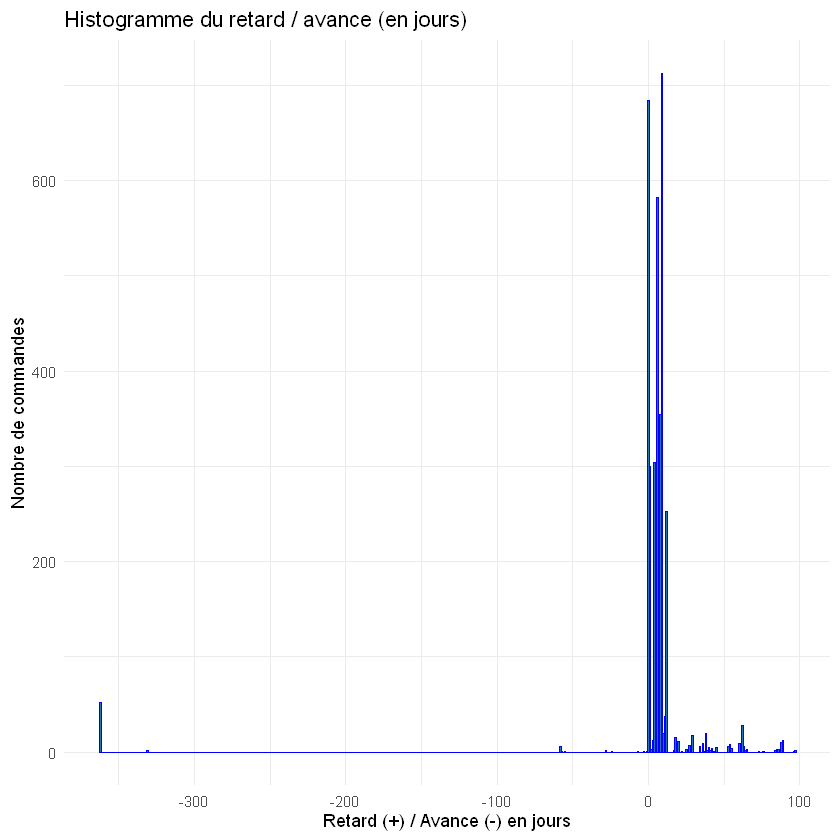

In [19]:
# 4) Histogrammes de retard/avance en jours (cdd - chd)
colis_df_clean <- colis_df_clean %>%
  mutate(delta_jours = as.numeric(cdd..date.réelle. - chd..date.prévue.))

p_hist_global <- ggplot(colis_df_clean, aes(x = delta_jours)) +
  geom_histogram(binwidth = 1, fill = "#1f78b4", color = "blue") +
  labs(
    title = "Histogramme du retard / avance (en jours)",
    x = "Retard (+) / Avance (-) en jours",
    y = "Nombre de commandes"
  ) +
  theme_minimal()

print(p_hist_global)

# A tibble: 10 × 4
   client                   delai_moyen taux_retard nb_commandes
   <chr>                          <dbl>       <dbl>        <int>
 1 PROXY                         12.4         0.991         1837
 2 CALZEDONIA                   -30.5         0.210          623
 3 PROXY TUNISIE                 10.4         1              435
 4 DMT                            0.937       0.785          382
 5 EMINENCE                       2.32        0.595          173
 6 ETAM                          -3.68        0.521           71
 7 ILUNA                          6.97        0.683           60
 8 FRALY                          4           1               20
 9 OASIS                          0           0               20
10 CONFECTION IDEALE DU SUD       0.25        0.167           12


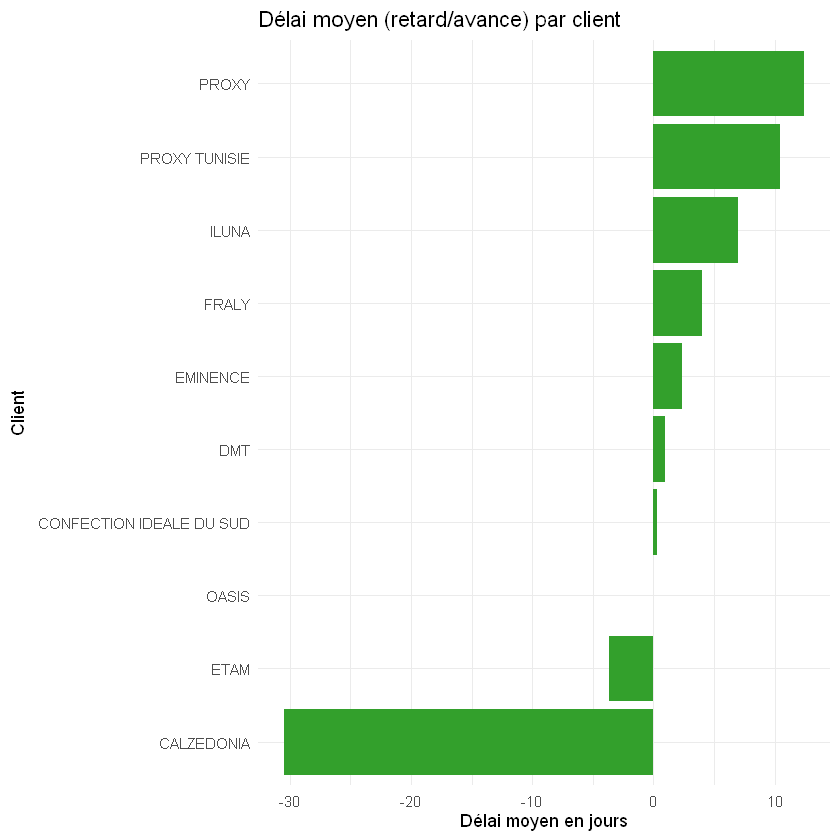

In [20]:
# 5) Comparaison par client
retard_client <- colis_df_clean %>%
  group_by(client) %>%
  summarise(
    delai_moyen = mean(delta_jours, na.rm = TRUE),
    taux_retard = mean(en_retard == "En retard", na.rm = TRUE),
    nb_commandes = n()
  ) %>%
  arrange(desc(nb_commandes))

print(head(retard_client, 10))

p_client <- ggplot(retard_client %>% filter(nb_commandes > 10), aes(x = reorder(client, delai_moyen), y = delai_moyen)) +
  geom_col(fill = "#33a02c") +
  coord_flip() +
  labs(
    title = "Délai moyen (retard/avance) par client",
    x = "Client",
    y = "Délai moyen en jours"
  ) +
  theme_minimal()

print(p_client)


# A tibble: 10 × 4
   produit_id delai_moyen taux_retard nb_commandes
        <int>       <dbl>       <dbl>        <int>
 1       1696      12          1               111
 2       1600       0.449      0.112            89
 3       1527       8.58       1                86
 4       1516       9.23       1                83
 5       1787       1.5        0.375            80
 6       1612       0.423      0.128            78
 7       1639     -35.2        0.127            71
 8       1526      11.0        1                70
 9       1894      16.6        1                68
10       1636    -133.         0.0308           65


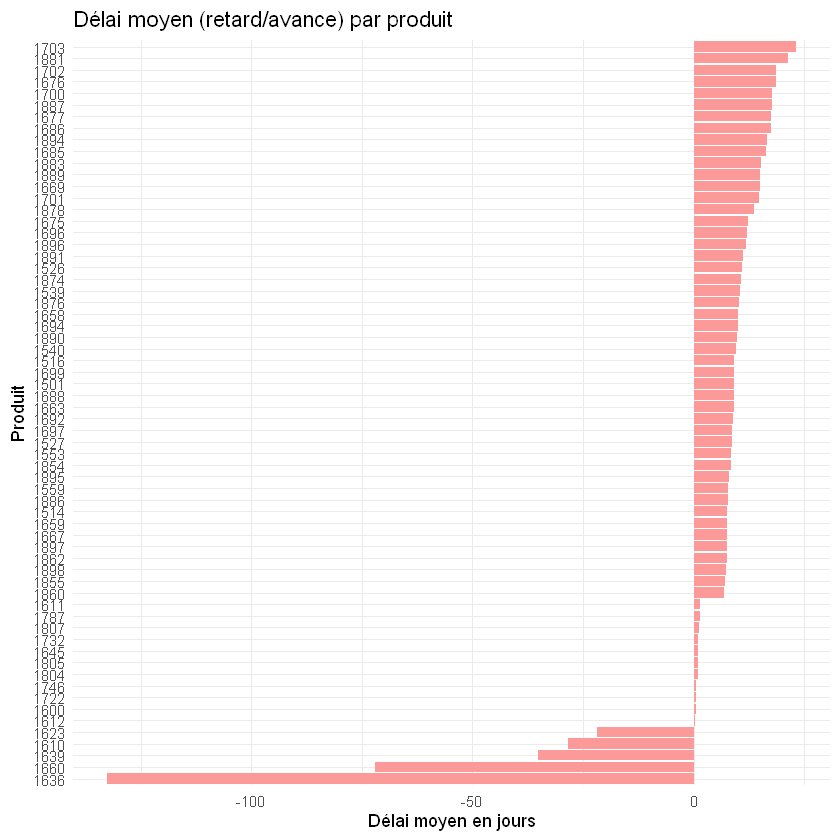

In [21]:
# 6) Comparaison par produit
retard_produit <- colis_df_clean %>%
  group_by(produit_id) %>%
  summarise(
    delai_moyen = mean(delta_jours, na.rm = TRUE),
    taux_retard = mean(en_retard == "En retard", na.rm = TRUE),
    nb_commandes = n()
  ) %>%
  arrange(desc(nb_commandes))

print(head(retard_produit, 10))

p_produit <- ggplot(retard_produit %>% filter(nb_commandes > 20), aes(x = reorder(as.factor(produit_id), delai_moyen), y = delai_moyen)) +
  geom_col(fill = "#fb9a99") +
  coord_flip() +
  labs(
    title = "Délai moyen (retard/avance) par produit",
    x = "Produit",
    y = "Délai moyen en jours"
  ) +
  theme_minimal()

print(p_produit)


# A tibble: 6 × 4
  site_id delai_moyen taux_retard nb_commandes
    <int>       <dbl>       <dbl>        <int>
1      NA        2.70       0.791         3439
2       2        7.49       0.896          183
3       1        3.36       0.364           11
4      17     -154          0.286            7
5      18     -362          0                1
6      20        8          1                1


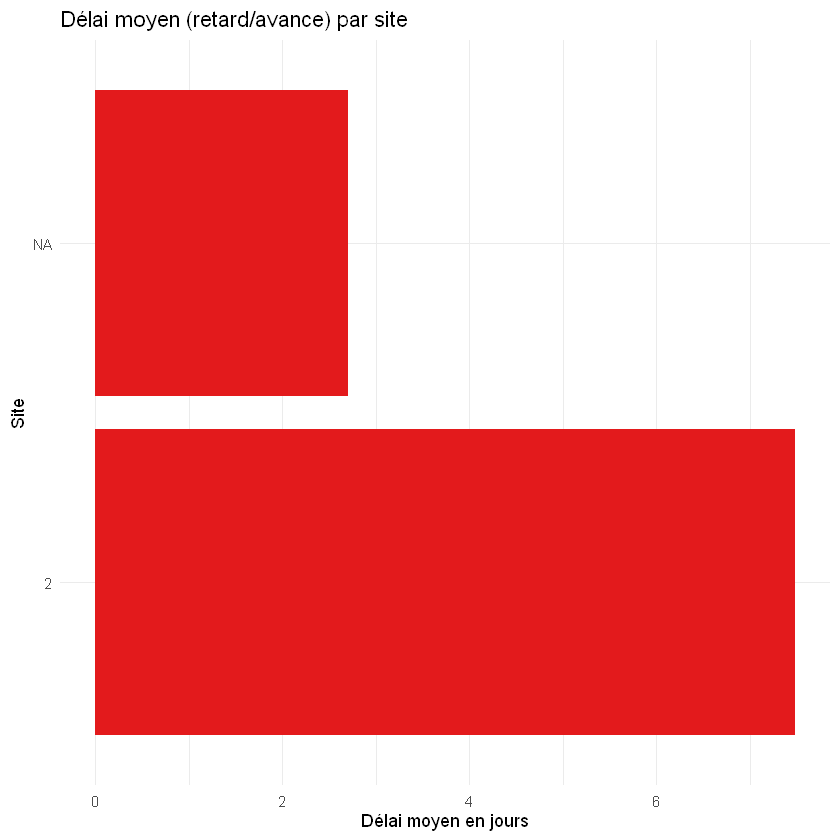

In [22]:
# 7) Comparaison par site
retard_site <- colis_df_clean %>%
  group_by(site_id) %>%
  summarise(
    delai_moyen = mean(delta_jours, na.rm = TRUE),
    taux_retard = mean(en_retard == "En retard", na.rm = TRUE),
    nb_commandes = n()
  ) %>%
  arrange(desc(nb_commandes))

print(head(retard_site, 10))

p_site <- ggplot(retard_site %>% filter(nb_commandes > 20), aes(x = reorder(as.factor(site_id), delai_moyen), y = delai_moyen)) +
  geom_col(fill = "#e31a1c") +
  coord_flip() +
  labs(
    title = "Délai moyen (retard/avance) par site",
    x = "Site",
    y = "Délai moyen en jours"
  ) +
  theme_minimal()

print(p_site)

Warning message:
"package 'lubridate' was built under R version 4.5.2"

Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




# A tibble: 6 × 4
   mois alerte_retard       n pourcentage
  <dbl> <chr>           <int>       <dbl>
1     1 Livré à temps      22       13.6 
2     1 Retard confirmé   140       86.4 
3     2 Livré à temps      23        7.32
4     2 Retard confirmé   291       92.7 
5     3 Livré à temps     134       22.2 
6     3 Retard confirmé   470       77.8 


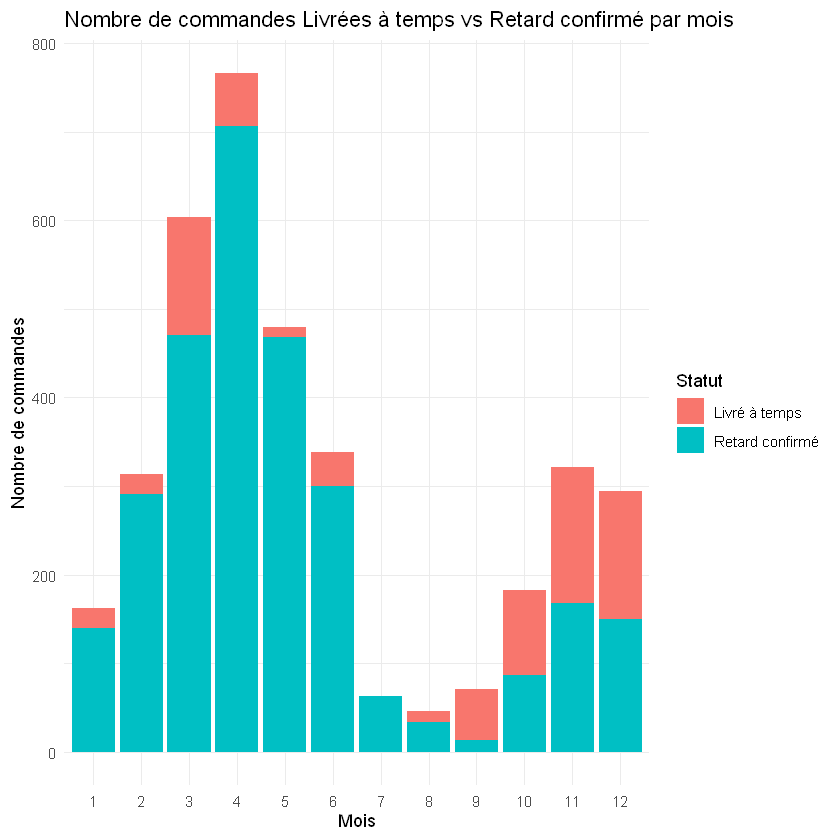

In [23]:
library(lubridate)

# Conversion minimale des dates utiles si besoin
possible_date_cols <- c("date_creation_commande", "chd..date.prévue.", "cdd..date.réelle.")
for (col in possible_date_cols) {
  if (col %in% names(colis_df_clean)) {
    colis_df_clean[[col]] <- as.Date(colis_df_clean[[col]])
  }
}

# On choisit la colonne de référence pour le mois
ref_date_col <- if ("chd..date.prévue." %in% names(colis_df_clean)) "chd..date.prévue." else "date_creation_commande"

# Création de la colonne mois (1 à 12)
colis_df_clean <- colis_df_clean %>%
  mutate(
    mois = month(.data[[ref_date_col]]),
    annee = year(.data[[ref_date_col]])
  )


# Regrouper par mois et alerte_retard
if (!"alerte_retard" %in% names(colis_df_clean)) {
  # Si la colonne n'existe pas, on crée un exemple binaire à partir du retard réel (cdd > chd)
  if (all(c("chd..date.prévue.", "cdd..date.réelle.") %in% names(colis_df_clean))) {
    colis_df_clean <- colis_df_clean %>%
      mutate(
        alerte_retard = ifelse(`cdd..date.réelle.` > `chd..date.prévue.`, "Retard confirmé", "Livré à temps")
      )
  }
}

# Table agrégée
retard_mois <- colis_df_clean %>%
  filter(!is.na(mois), !is.na(alerte_retard)) %>%
  group_by(mois, alerte_retard) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(mois) %>%
  mutate(pourcentage = 100 * n / sum(n)) %>%
  ungroup()

print(head(retard_mois))

# Graphique 1 : histogramme empilé (barplot) par mois en valeurs absolues
plot_hist_counts <- ggplot(retard_mois, aes(x = factor(mois), y = n, fill = alerte_retard)) +
  geom_col(position = "stack") +
  labs(
    title = "Nombre de commandes Livrées à temps vs Retard confirmé par mois",
    x = "Mois",
    y = "Nombre de commandes",
    fill = "Statut"
  ) +
  theme_minimal()

print(plot_hist_counts)

# A tibble: 2 × 4
   mois alerte_retard       n pourcentage
  <dbl> <chr>           <int>       <dbl>
1     1 Livré à temps      22        13.6
2     1 Retard confirmé   140        86.4


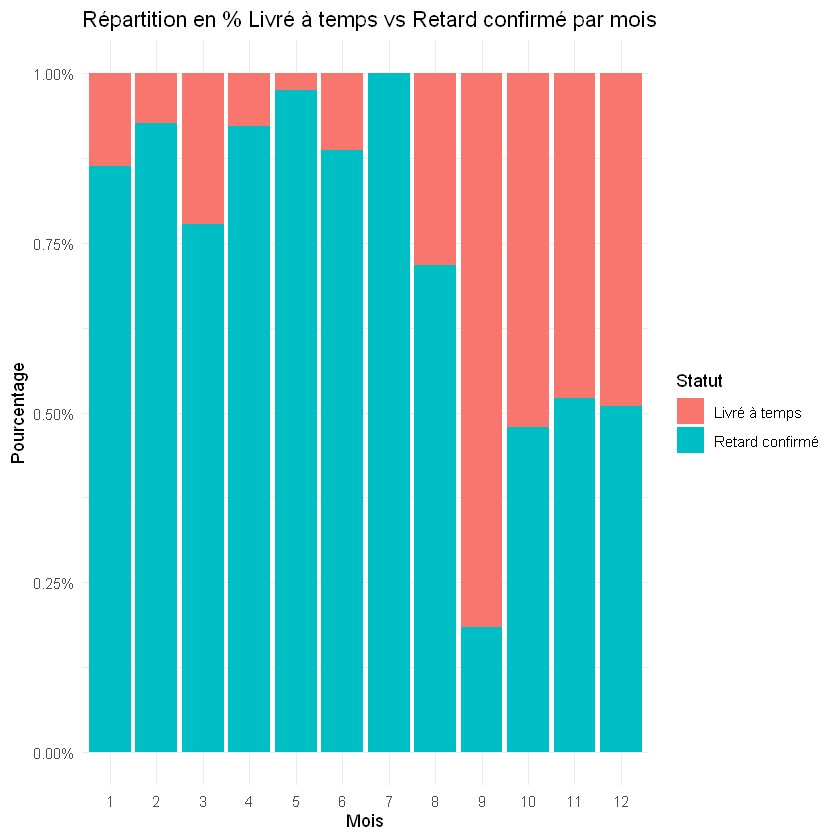

In [24]:

# Graphique 2 : histogramme en pourcentage par mois
plot_hist_percent <- ggplot(retard_mois, aes(x = factor(mois), y = pourcentage, fill = alerte_retard)) +
  geom_col(position = "fill") +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) +
  labs(
    title = "Répartition en % Livré à temps vs Retard confirmé par mois",
    x = "Mois",
    y = "Pourcentage",
    fill = "Statut"
  ) +
  theme_minimal()

print(plot_hist_percent)

retard_janvier <- retard_mois %>% filter(mois == 1)
print(retard_janvier)



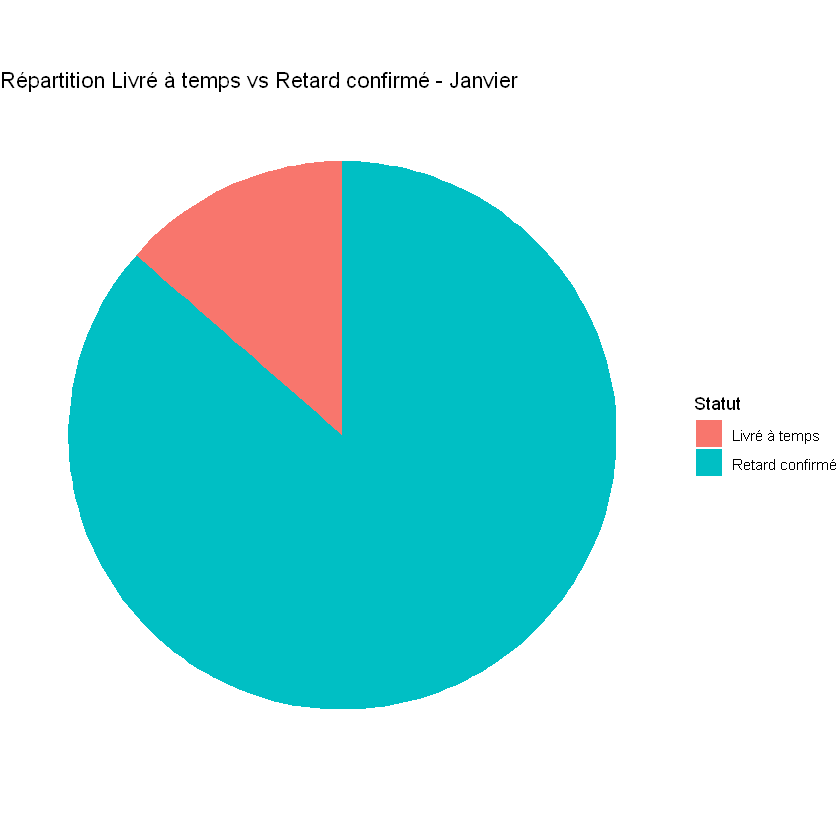

In [25]:
plot_pie_janvier <- ggplot(retard_janvier, aes(x = "", y = n, fill = alerte_retard)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  labs(
    title = "Répartition Livré à temps vs Retard confirmé - Janvier",
    x = NULL,
    y = NULL,
    fill = "Statut"
  ) +
  theme_void()

print(plot_pie_janvier)

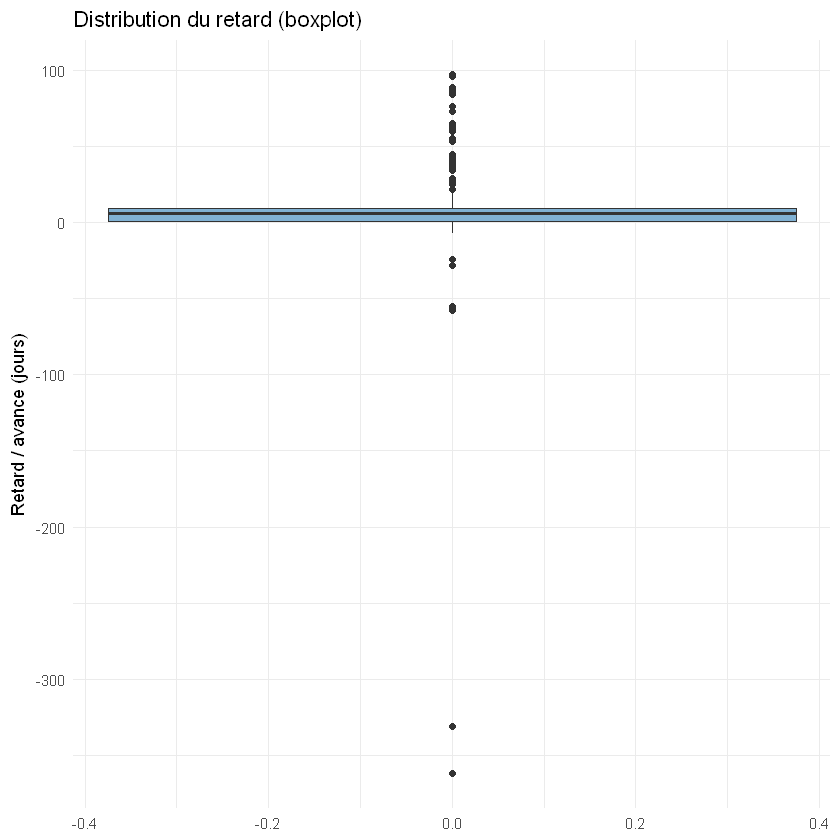

In [26]:
#Boxplot du retard (très important en statistique)
ggplot(colis_df_clean, aes(y = delta_jours)) +
  geom_boxplot(fill = "#80b1d3") +
  labs(
    title = "Distribution du retard (boxplot)",
    y = "Retard / avance (jours)"
  ) +
  theme_minimal()


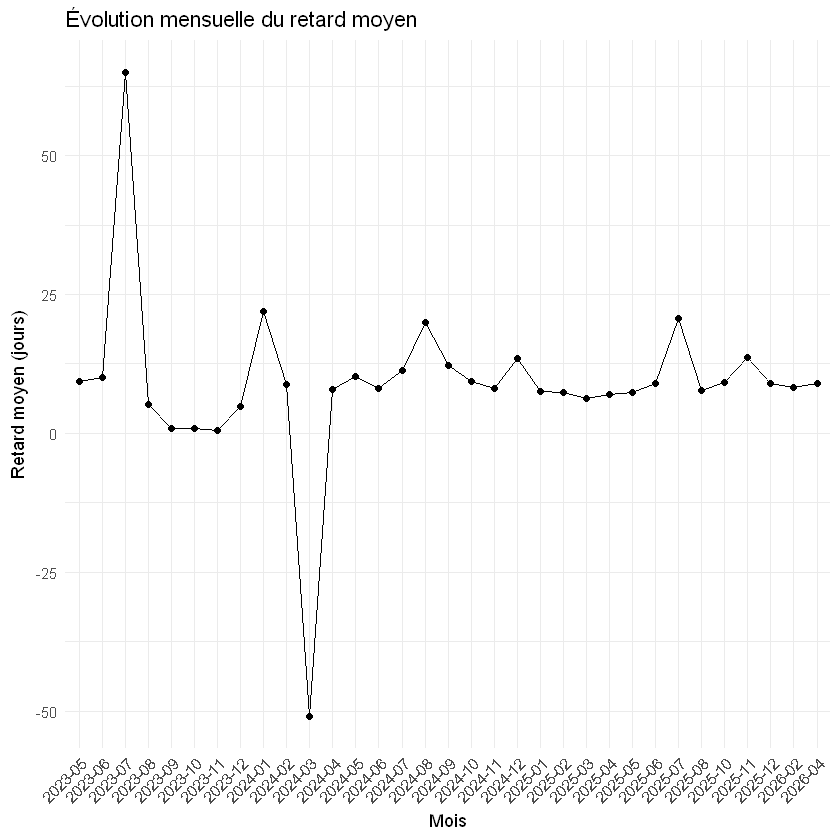

In [27]:
#Évolution temporelle des retards
retard_par_mois <- colis_df_clean %>%
  mutate(mois = format(chd..date.prévue., "%Y-%m")) %>%
  group_by(mois) %>%
  summarise(retard_moyen = mean(delta_jours, na.rm = TRUE))

ggplot(retard_par_mois, aes(x = mois, y = retard_moyen, group = 1)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Évolution mensuelle du retard moyen",
    x = "Mois",
    y = "Retard moyen (jours)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [28]:
#Heatmap Client × Site
library(tidyr)

heat_data <- colis_df_clean %>%
  group_by(client, site_id) %>%
  summarise(retard_moyen = mean(delta_jours, na.rm = TRUE)) %>%
  drop_na()

ggplot(heat_data, aes(x = client, y = as.factor(site_id), fill = retard_moyen)) +
  geom_tile() +
  scale_fill_gradient2(low = "green", mid = "white", high = "red") +
  labs(
    title = "Heatmap du retard moyen par client et site",
    x = "Client",
    y = "Site"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


ERROR: Error in library(tidyr): there is no package called 'tidyr'
